# Homebound 종합 EDA (개·고양이)

보호종료동물 데이터(789,874건, 2019-2025) 중 **개·고양이만** 대상으로 한 전방위 탐색적 분석.

| Part | 내용 |
|------|------|
| 1 | 전국 연도별 종합 추이 |
| 2 | 시도별 종합 비교 (2024 스냅샷) |
| 3 | 시도별 × 연도별 추이 히트맵 |
| 4 | 월별·요일별 계절성 패턴 |
| 5 | 개 vs 고양이 비교 |
| 6 | 나이·성별·중성화별 입양률 |
| 7 | 보호소 성과 분석 |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

PAL = {'입양':'#2ecc71','안락사':'#e74c3c','자연사':'#95a5a6',
       '반환':'#3498db','기타':'#f39c12','개':'#e67e22','고양이':'#9b59b6'}

DATA = '../02_outputs/data/'
FIG  = '../02_outputs/figures/'

monthly  = pd.read_csv(f'{DATA}agg_monthly_outcome.csv')
region   = pd.read_csv(f'{DATA}agg_region_yearly.csv')
breed    = pd.read_csv(f'{DATA}agg_breed_adoption.csv')
shelter  = pd.read_csv(f'{DATA}agg_shelter_performance.csv')
multidim = pd.read_csv(f'{DATA}agg_adoption_multidim.csv')
temporal = pd.read_csv(f'{DATA}agg_temporal_pattern.csv')

# 파생 컬럼
region['자연사율'] = (region['자연사건수']/region['총건수']*100).round(2)
region['반환율']   = (region['반환건수']/region['총건수']*100).round(2)
region['사망률']   = region['안락사율'] + region['자연사율']

# ★ 개·고양이만 필터
breed    = breed[breed['동물종류'].isin(['개','고양이'])]
multidim = multidim[multidim['동물종류'].isin(['개','고양이'])]
temporal = temporal[temporal['동물종류'].isin(['개','고양이'])]

# region 데이터는 개_건수, 고양이_건수로 재집계
region['개고양이_건수'] = region['개_건수'] + region['고양이_건수']

# 2025 제외
R = region[region['접수년도']<=2024].copy()
M = monthly[monthly['접수년도']<=2024].copy()
T = temporal[temporal['접수년도']<=2024].copy()

print(f'로드 완료 (개·고양이 필터 적용)')
print(f'  breed: {len(breed)}개 품종')
print(f'  multidim: {len(multidim):,}행')
print(f'  temporal: {len(T):,}행')

로드 완료 (개·고양이 필터 적용)
  breed: 146개 품종
  multidim: 1,783행
  temporal: 1,008행


---
## Part 1. 전국 연도별 종합 추이

In [2]:
# 전국 연도별 집계 (region 기반 — 개+고양이 건수 사용)
nat = R.groupby('접수년도').agg(
    총건수=('총건수','sum'), 입양=('입양건수','sum'),
    안락사=('안락사건수','sum'), 자연사=('자연사건수','sum'),
    반환=('반환건수','sum'), 개=('개_건수','sum'), 고양이=('고양이_건수','sum')
).reset_index()
for c in ['입양','안락사','자연사','반환']:
    nat[f'{c}률'] = (nat[c]/nat['총건수']*100).round(1)
nat['사망률'] = nat['안락사률'] + nat['자연사률']
nat['전년대비'] = nat['총건수'].pct_change().mul(100).round(1)
nat['개비중'] = (nat['개']/nat['총건수']*100).round(1)
nat['고양이비중'] = (nat['고양이']/nat['총건수']*100).round(1)

display_cols = ['접수년도','총건수','전년대비','입양률','안락사률','자연사률','사망률','반환률','개비중','고양이비중']
print(nat[display_cols].to_string(index=False))

 접수년도    총건수  전년대비  입양률  안락사률  자연사률  사망률  반환률  개비중  고양이비중
 2019 133429   NaN 30.2  25.7  29.0 54.7 12.3 74.1   21.5
 2020 128717  -3.5 33.9  23.8  27.9 51.7 11.6 72.0   23.7
 2021 116568  -9.4 36.4  19.8  28.6 48.4 12.2 71.0   26.1
 2022 111672  -4.2 31.2  21.4  30.0 51.4 12.6 70.5   27.1
 2023 110717  -0.9 27.8  23.3  30.8 54.1 12.3 71.1   26.8
 2024 103282  -6.7 27.7  23.7  30.1 53.8 11.8 72.1   25.5


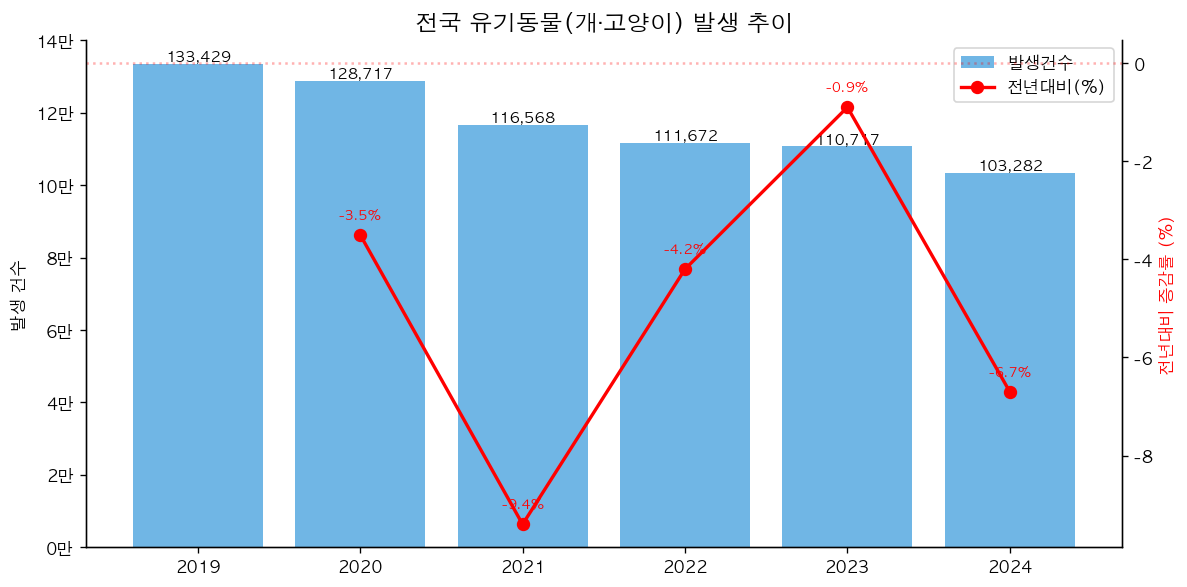

In [3]:
# 1-1. 발생건수 + 전년대비 증감률
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars = ax1.bar(nat['접수년도'], nat['총건수'], color='#3498db', alpha=0.7, label='발생건수')
for b, v in zip(bars, nat['총건수']):
    ax1.text(b.get_x()+b.get_width()/2, v+800, f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold')

ax2.plot(nat['접수년도'], nat['전년대비'], 'ro-', linewidth=2, markersize=7, label='전년대비(%)', zorder=5)
for x, y in zip(nat['접수년도'], nat['전년대비']):
    if not np.isnan(y):
        ax2.annotate(f'{y:+.1f}%', (x,y), textcoords='offset points', xytext=(0,10), ha='center', fontsize=8, color='red')

ax1.set_ylabel('발생 건수')
ax2.set_ylabel('전년대비 증감률 (%)', color='red')
ax2.axhline(0, color='red', linestyle=':', alpha=0.3)
ax1.set_title('전국 유기동물(개·고양이) 발생 추이', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/10000:.0f}만'))
ax1.set_xticks(nat['접수년도'])
ax1.spines['top'].set_visible(False); ax2.spines['top'].set_visible(False)
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIG}EDA_발생추이.png', dpi=150, bbox_inches='tight')
plt.show()

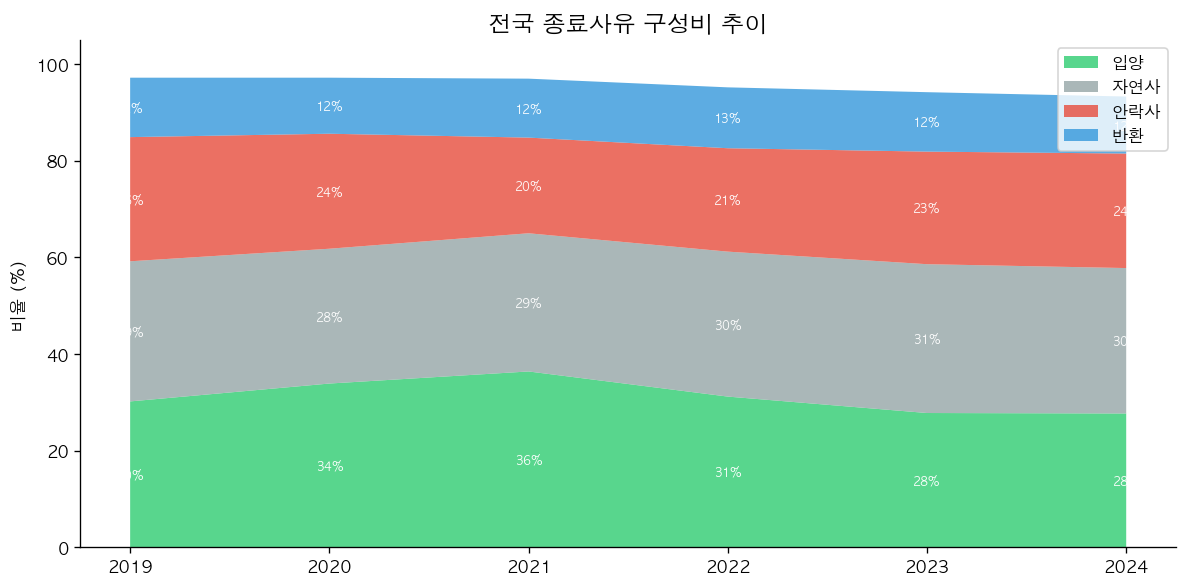

In [4]:
# 1-2. 종료사유 구성비 추이 (면적 차트)
fig, ax = plt.subplots(figsize=(10, 5))
causes = ['입양률','자연사률','안락사률','반환률']
colors = [PAL['입양'],PAL['자연사'],PAL['안락사'],PAL['반환']]
labels = ['입양','자연사','안락사','반환']

ax.stackplot(nat['접수년도'], *[nat[c] for c in causes], labels=labels, colors=colors, alpha=0.8)
for yr in nat['접수년도']:
    row = nat[nat['접수년도']==yr].iloc[0]
    cum = 0
    for c, lbl in zip(causes, labels):
        val = row[c]
        if val > 8:
            ax.text(yr, cum+val/2, f'{val:.0f}%', ha='center', va='center', fontsize=7, fontweight='bold', color='white')
        cum += val

ax.set_ylabel('비율 (%)')
ax.set_title('전국 종료사유 구성비 추이', fontsize=14, fontweight='bold')
ax.set_xticks(nat['접수년도']); ax.legend(loc='upper right')
ax.set_ylim(0,105); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_종료사유구성비.png', dpi=150, bbox_inches='tight')
plt.show()

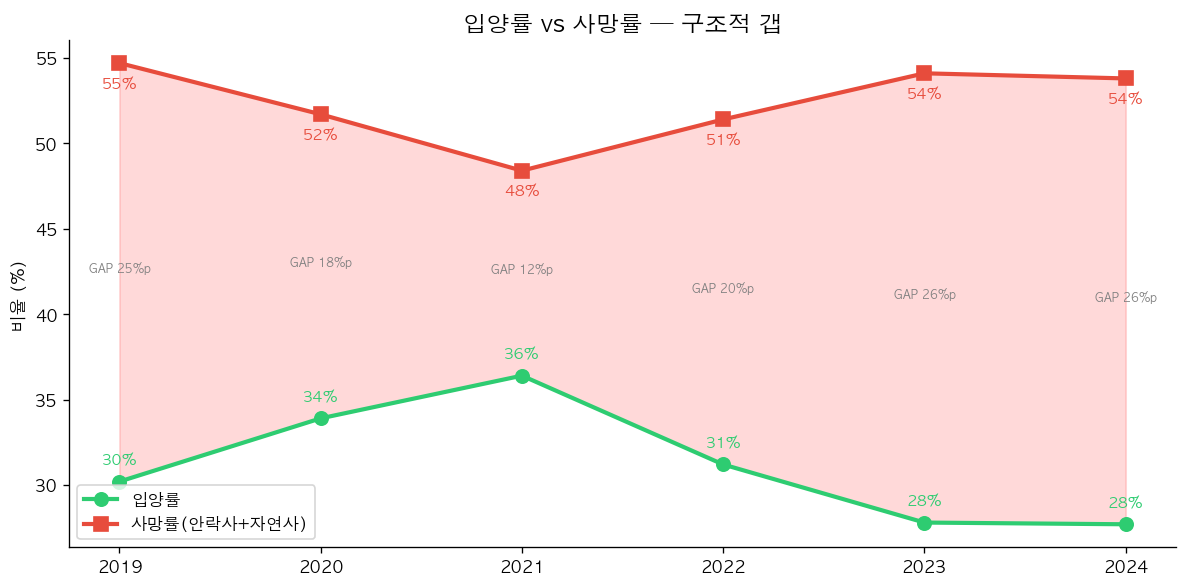

In [5]:
# 1-3. 입양률 vs 사망률 갭
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nat['접수년도'], nat['입양률'], 'o-', color=PAL['입양'], lw=2.5, ms=8, label='입양률')
ax.plot(nat['접수년도'], nat['사망률'], 's-', color=PAL['안락사'], lw=2.5, ms=8, label='사망률(안락사+자연사)')
ax.fill_between(nat['접수년도'], nat['입양률'], nat['사망률'], alpha=0.15, color='red')

for yr in nat['접수년도']:
    r = nat[nat['접수년도']==yr].iloc[0]
    ax.annotate(f'{r["입양률"]:.0f}%', (yr,r['입양률']), textcoords='offset points', xytext=(0,10), ha='center', fontsize=9, color=PAL['입양'])
    ax.annotate(f'{r["사망률"]:.0f}%', (yr,r['사망률']), textcoords='offset points', xytext=(0,-15), ha='center', fontsize=9, color=PAL['안락사'])
    gap = r['사망률'] - r['입양률']
    ax.annotate(f'GAP {gap:.0f}%p', (yr,(r['입양률']+r['사망률'])/2), ha='center', fontsize=7, color='gray', fontstyle='italic')

ax.set_title('입양률 vs 사망률 — 구조적 갭', fontsize=14, fontweight='bold')
ax.set_ylabel('비율 (%)'); ax.set_xticks(nat['접수년도'])
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_입양vs사망갭.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 2. 시도별 종합 비교 (2024 스냅샷)

In [6]:
r24 = R[R['접수년도']==2024].copy().sort_values('입양률', ascending=False)
print(r24[['시도','총건수','입양률','안락사율','자연사율','반환율','사망률']].to_string(index=False))

     시도   총건수   입양률  안락사율  자연사율   반환율   사망률
   경상북도  8387 39.10 28.94 19.72 10.48 48.66
  대전광역시  1562 34.70 13.76 11.72 39.24 25.48
  대구광역시  4402 34.42 17.42 35.69 10.70 53.11
전북특별자치도  8195 34.23 17.73 31.91  7.53 49.64
   충청북도  4271 33.83 27.72 18.68 14.21 46.40
  인천광역시  5626 31.91 12.96 31.18 14.20 44.14
세종특별자치시   468 31.84 30.34 30.98  1.92 61.32
   충청남도  8748 30.29 26.47 24.95  9.53 51.42
   경상남도  8952 29.84 25.38 26.25  9.70 51.63
강원특별자치도  4861 26.83 22.90 32.30 15.33 55.20
  서울특별시  4593 26.74 13.85 32.46 22.32 46.31
  광주광역시  2476 24.35 14.58 40.59 13.09 55.17
  부산광역시  4896 23.77  2.59 59.23 10.74 61.82
    경기도 20702 22.02 28.79 24.56 13.60 53.35
   전라남도  8564 21.65 27.94 39.42  7.96 67.36
  울산광역시  2859 16.16 11.05 60.72  6.89 71.77
제주특별자치도  3720 15.11 54.92 18.31  5.48 73.23


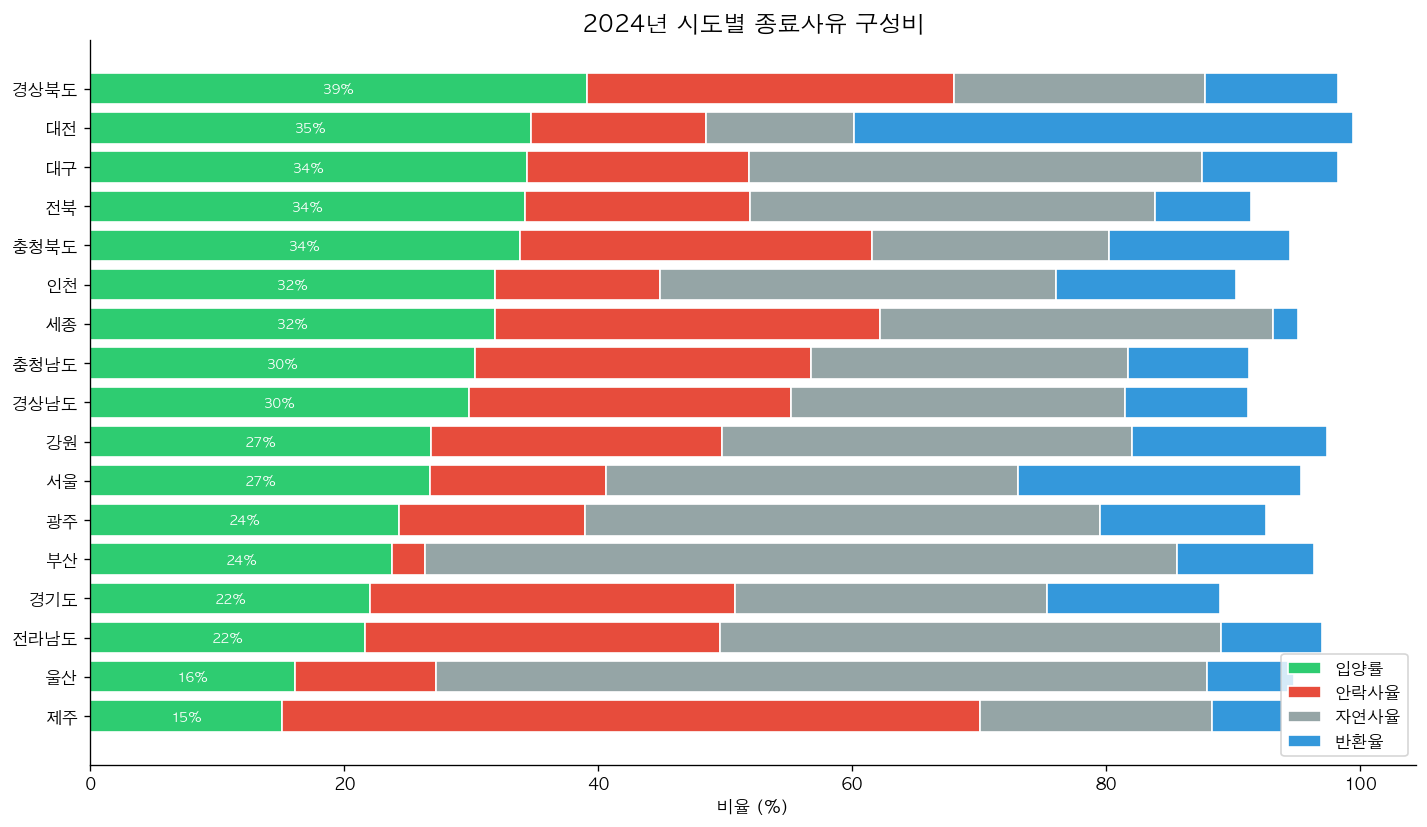

In [7]:
# 2-1. 시도별 종료사유 수평 스택 바
r24s = r24.sort_values('입양률')
fig, ax = plt.subplots(figsize=(12, 7))
y = range(len(r24s))

cols = [('입양률',PAL['입양'],'입양률'),('안락사율',PAL['안락사'],'안락사율'),
        ('자연사율',PAL['자연사'],'자연사율'),('반환율',PAL['반환'],'반환율')]
left = np.zeros(len(r24s))
for col, color, label in cols:
    ax.barh(y, r24s[col], left=left, color=color, label=label, edgecolor='white')
    left = left + r24s[col].values

ax.set_yticks(y)
ynames = [s.replace('특별자치도','').replace('특별자치시','').replace('광역시','').replace('특별시','') for s in r24s['시도']]
ax.set_yticklabels(ynames)

for i, (_, row) in enumerate(r24s.iterrows()):
    ax.text(row['입양률']/2, i, f'{row["입양률"]:.0f}%', ha='center', va='center', fontsize=8, fontweight='bold', color='white')

ax.set_xlabel('비율 (%)'); ax.set_title('2024년 시도별 종료사유 구성비', fontsize=14, fontweight='bold')
ax.legend(loc='lower right'); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_시도별구성비.png', dpi=150, bbox_inches='tight')
plt.show()

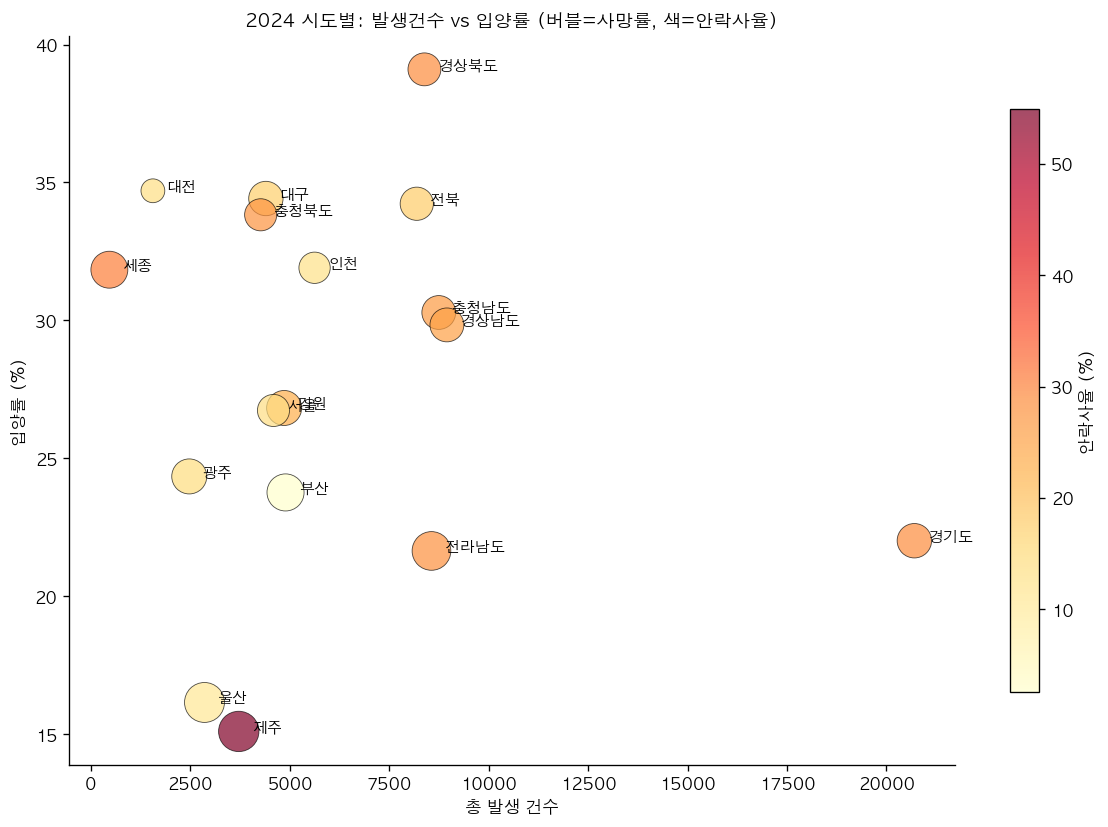

In [8]:
# 2-2. 시도별 발생건수 vs 입양률 버블차트
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(r24['총건수'], r24['입양률'],
                     s=r24['사망률']*8, c=r24['안락사율'], cmap='YlOrRd',
                     alpha=0.7, edgecolors='black', linewidth=0.5)
for _, row in r24.iterrows():
    name = row['시도'].replace('특별자치도','').replace('특별자치시','').replace('광역시','').replace('특별시','')
    ax.annotate(name, (row['총건수'],row['입양률']), textcoords='offset points', xytext=(8,0), fontsize=9)

plt.colorbar(scatter, ax=ax, label='안락사율 (%)', shrink=0.8)
ax.set_xlabel('총 발생 건수'); ax.set_ylabel('입양률 (%)')
ax.set_title('2024 시도별: 발생건수 vs 입양률 (버블=사망률, 색=안락사율)', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_시도별산점도.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 3. 시도별 × 연도별 추이 히트맵

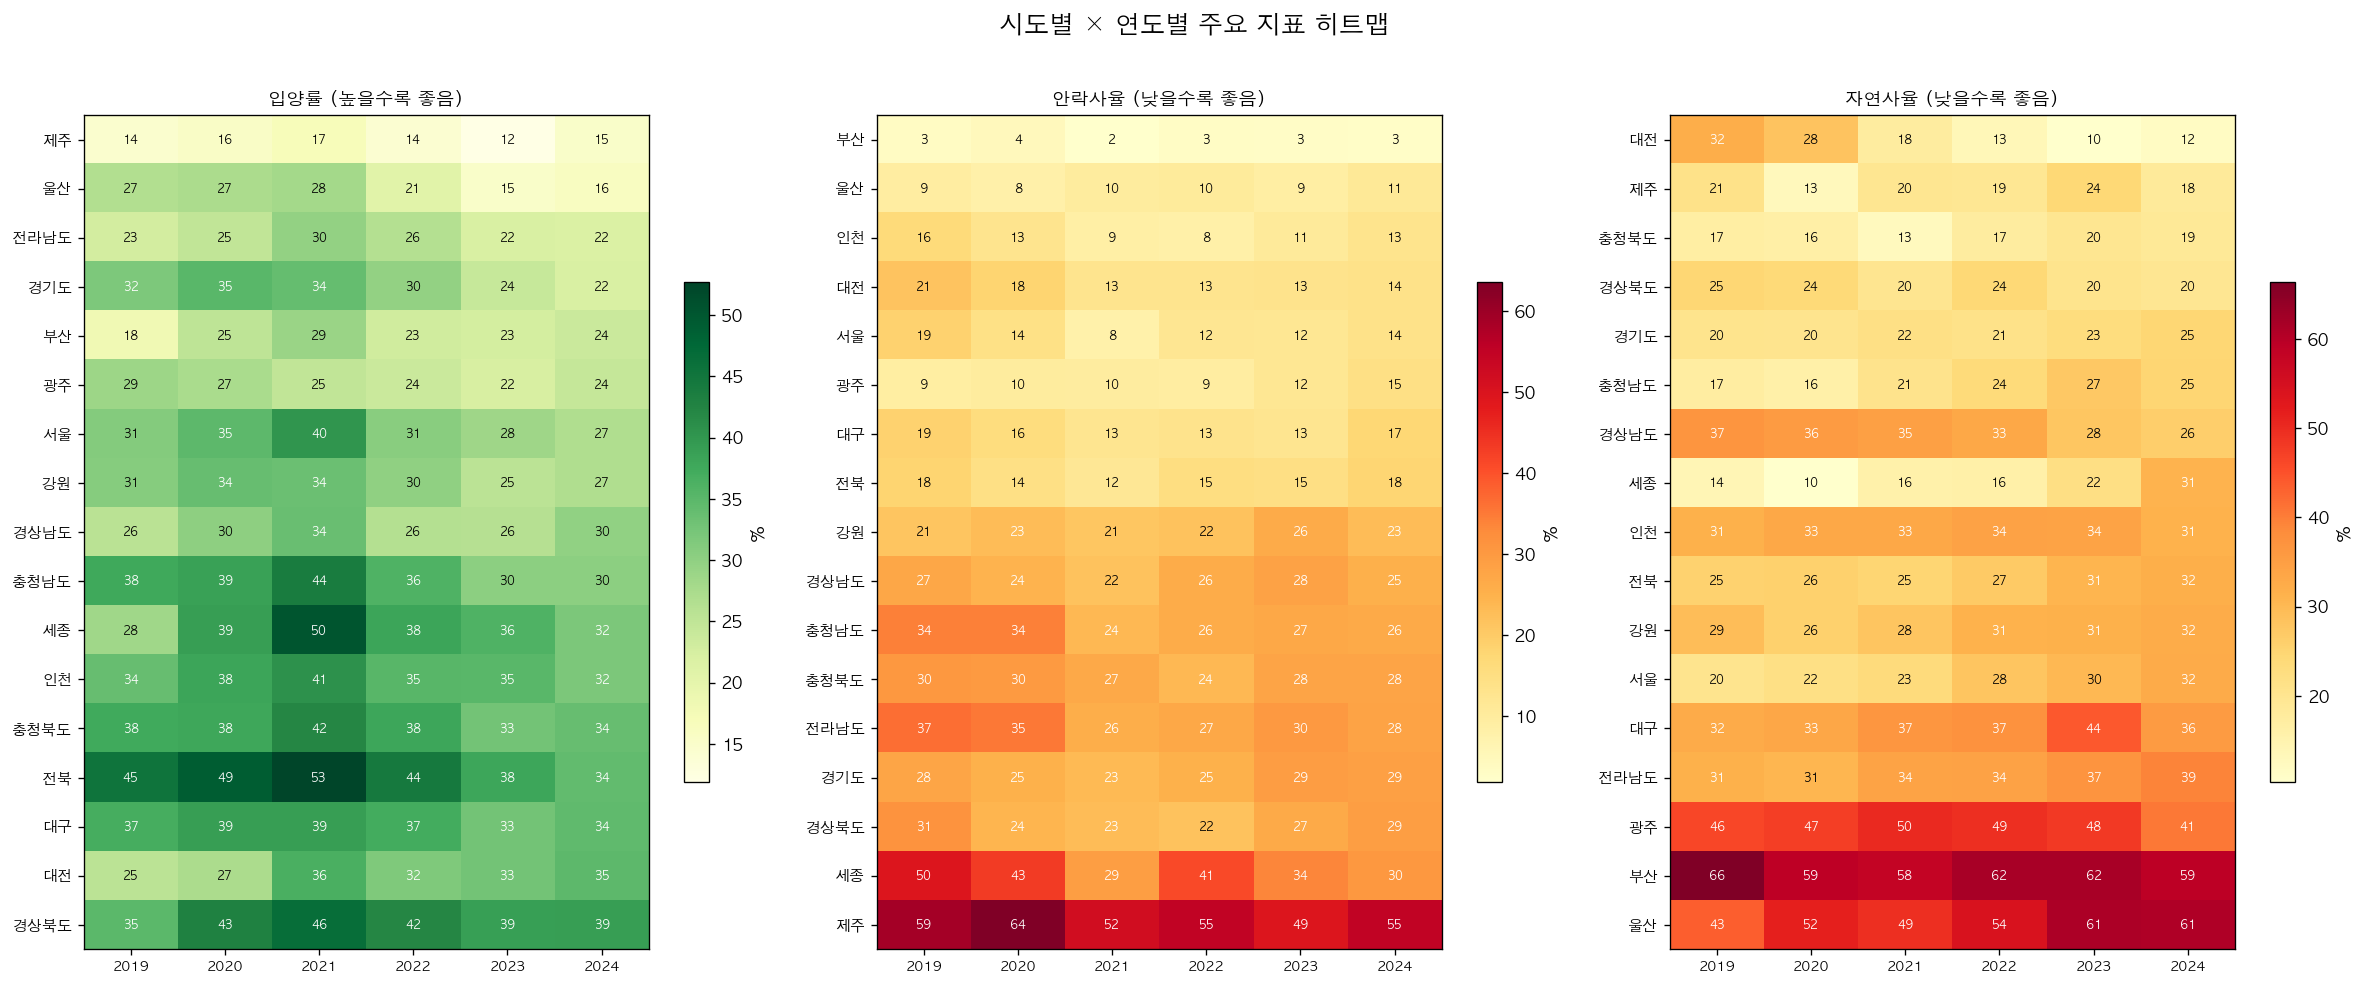

In [9]:
# 3-1. 3대 지표 히트맵 (입양률 / 안락사율 / 자연사율)
metrics_hm = [('입양률','YlGn','높을수록 좋음'),('안락사율','YlOrRd','낮을수록 좋음'),('자연사율','YlOrRd','낮을수록 좋음')]

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, (metric, cmap, note) in zip(axes, metrics_hm):
    pv = R.pivot_table(index='시도', columns='접수년도', values=metric, aggfunc='first')
    pv = pv.sort_values(2024, ascending=True)
    im = ax.imshow(pv.values, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(pv.columns))); ax.set_xticklabels(pv.columns, fontsize=8)
    ax.set_yticks(range(len(pv.index)))
    ynames = [s.replace('특별자치도','').replace('특별자치시','').replace('광역시','').replace('특별시','') for s in pv.index]
    ax.set_yticklabels(ynames, fontsize=9)
    for i in range(len(pv.index)):
        for j in range(len(pv.columns)):
            v = pv.iloc[i,j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7,
                        color='white' if v > np.nanmean(pv.values) else 'black')
    ax.set_title(f'{metric} ({note})', fontweight='bold', fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.6, label='%')

plt.suptitle('시도별 × 연도별 주요 지표 히트맵', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_시도연도히트맵.png', dpi=150, bbox_inches='tight')
plt.show()

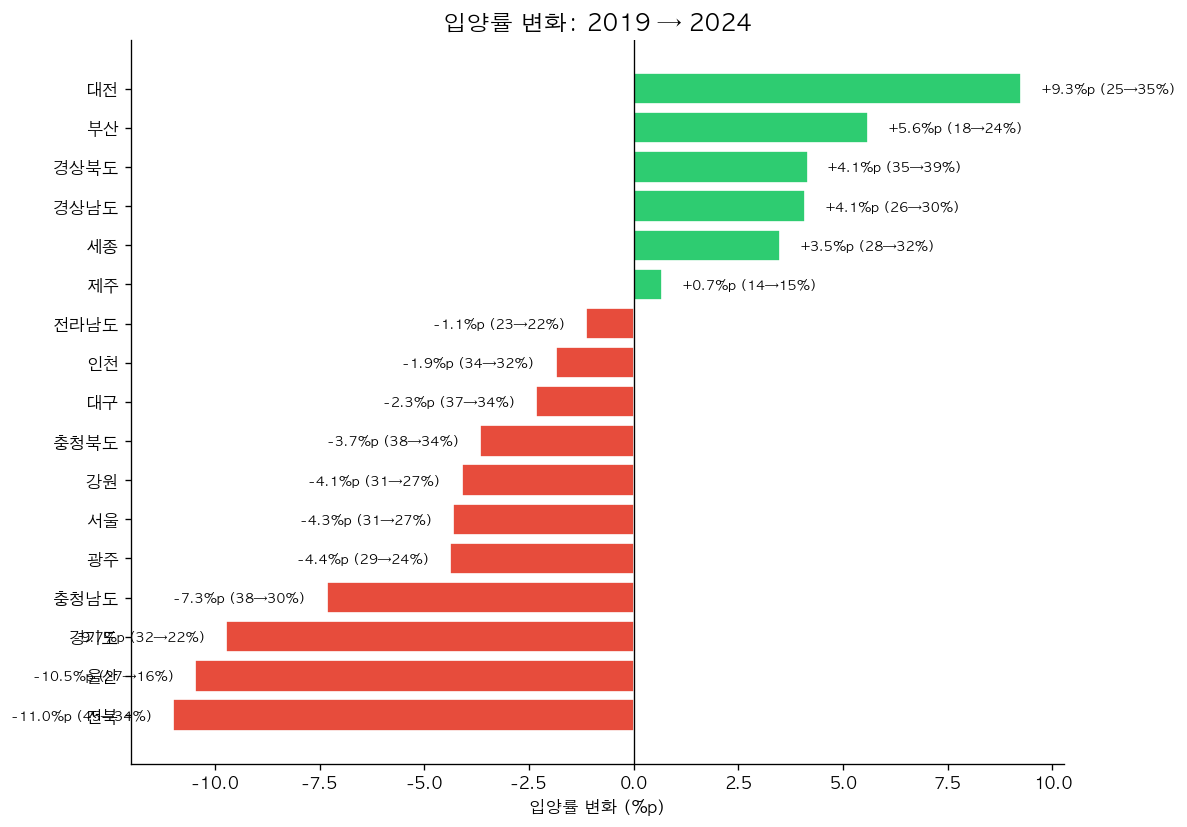

In [10]:
# 3-2. 입양률 변화: 2019 → 2024
r19 = R[R['접수년도']==2019][['시도','입양률']].rename(columns={'입양률':'2019'})
r24c = R[R['접수년도']==2024][['시도','입양률']].rename(columns={'입양률':'2024'})
chg = r19.merge(r24c, on='시도')
chg['변화'] = chg['2024'] - chg['2019']
chg = chg.sort_values('변화')

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v<0 else '#2ecc71' for v in chg['변화']]
ax.barh(range(len(chg)), chg['변화'], color=colors, edgecolor='white')
ax.set_yticks(range(len(chg)))
ynames = [s.replace('특별자치도','').replace('특별자치시','').replace('광역시','').replace('특별시','') for s in chg['시도']]
ax.set_yticklabels(ynames)
ax.axvline(0, color='black', linewidth=0.8)
for i, (_, row) in enumerate(chg.iterrows()):
    sign = '+' if row['변화']>0 else ''
    ax.text(row['변화']+(0.5 if row['변화']>=0 else -0.5), i,
            f'{sign}{row["변화"]:.1f}%p ({row["2019"]:.0f}→{row["2024"]:.0f}%)',
            va='center', fontsize=8, ha='left' if row['변화']>=0 else 'right')

ax.set_xlabel('입양률 변화 (%p)'); ax.set_title('입양률 변화: 2019 → 2024', fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_시도별입양률변화.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4. 월별·요일별 계절성 패턴

In [11]:
# 월별 집계
m_agg = M.groupby(['접수월','종료사유_정제'])['건수'].sum().reset_index()
m_total = M.groupby('접수월')['건수'].sum().reset_index().rename(columns={'건수':'총건수'})
m_agg = m_agg.merge(m_total, on='접수월')
m_agg['비율'] = (m_agg['건수']/m_agg['총건수']*100).round(1)
m_pivot = m_agg.pivot_table(index='접수월', columns='종료사유_정제', values='비율', fill_value=0)

m_by_year = M.groupby(['접수년도','접수월'])['건수'].sum().reset_index()
m_avg = m_by_year.groupby('접수월')['건수'].mean().reset_index().rename(columns={'건수':'평균건수'})

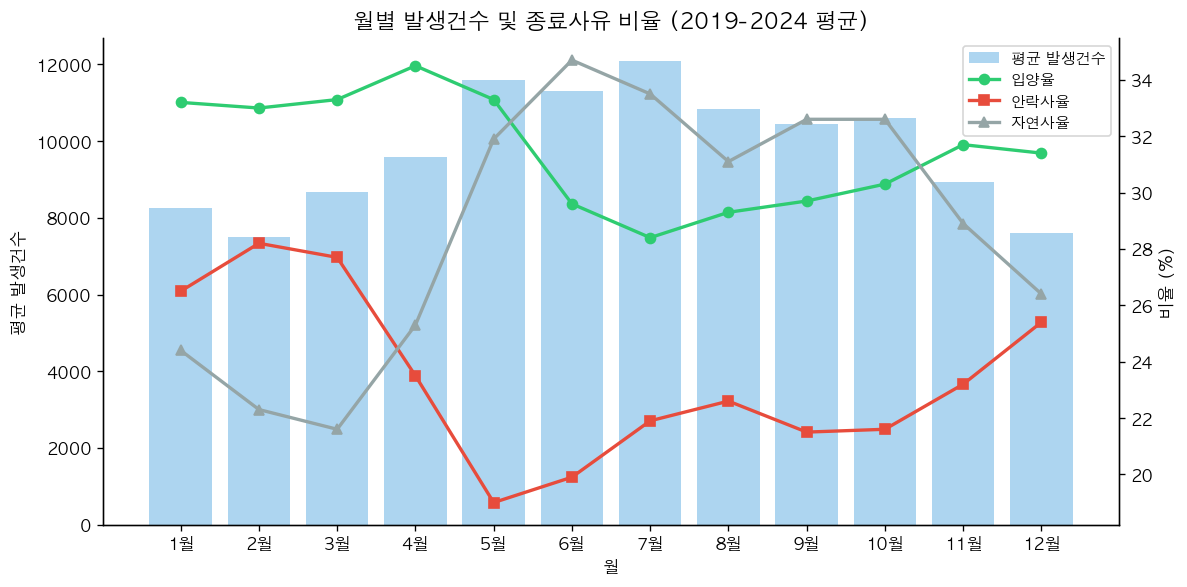

In [12]:
# 4-1. 월별 발생건수 + 입양률/안락사율/자연사율
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(m_avg['접수월'], m_avg['평균건수'], color='#3498db', alpha=0.4, label='평균 발생건수')
for cause, color, marker in [('입양',PAL['입양'],'o'),('안락사',PAL['안락사'],'s'),('자연사',PAL['자연사'],'^')]:
    ax2.plot(m_pivot.index, m_pivot[cause], f'{marker}-', color=color, lw=2, ms=6, label=f'{cause}율', zorder=5)

ax1.set_xlabel('월'); ax1.set_ylabel('평균 발생건수'); ax2.set_ylabel('비율 (%)')
ax1.set_xticks(range(1,13)); ax1.set_xticklabels([f'{m}월' for m in range(1,13)])
ax1.set_title('월별 발생건수 및 종료사유 비율 (2019-2024 평균)', fontsize=13, fontweight='bold')
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper right', fontsize=9)
ax1.spines['top'].set_visible(False); ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_월별패턴.png', dpi=150, bbox_inches='tight')
plt.show()

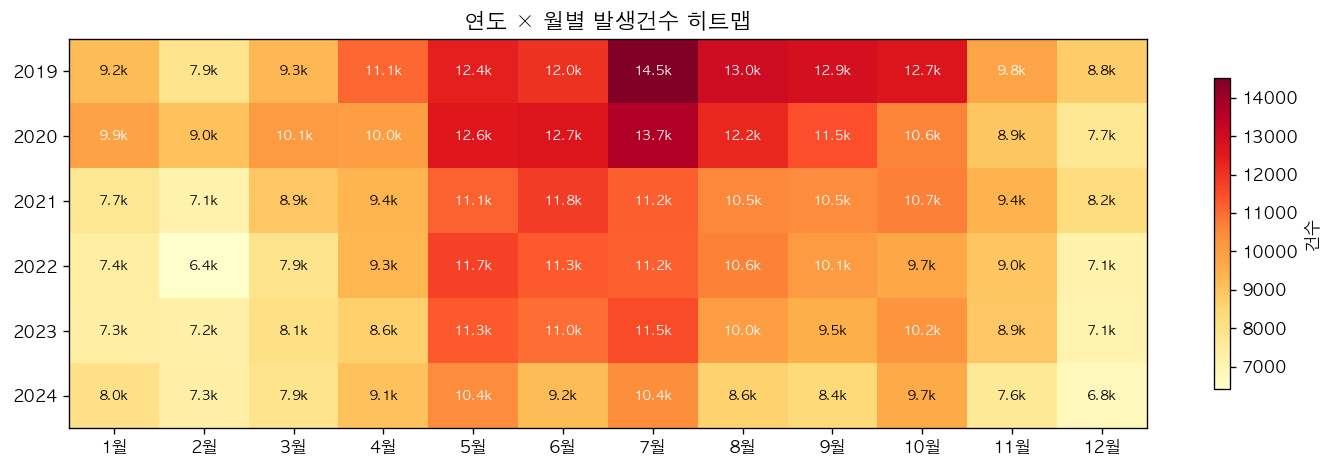

In [13]:
# 4-2. 연도×월 발생건수 히트맵
ym = m_by_year.pivot_table(index='접수년도', columns='접수월', values='건수', fill_value=0)
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(ym.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(12)); ax.set_xticklabels([f'{m}월' for m in range(1,13)])
ax.set_yticks(range(len(ym.index))); ax.set_yticklabels(ym.index)
for i in range(len(ym.index)):
    for j in range(12):
        v = ym.iloc[i,j]
        ax.text(j,i,f'{v/1000:.1f}k',ha='center',va='center',fontsize=8,
                color='white' if v>ym.values.mean() else 'black')
plt.colorbar(im, ax=ax, label='건수', shrink=0.8)
ax.set_title('연도 × 월별 발생건수 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG}EDA_연도월히트맵.png', dpi=150, bbox_inches='tight')
plt.show()

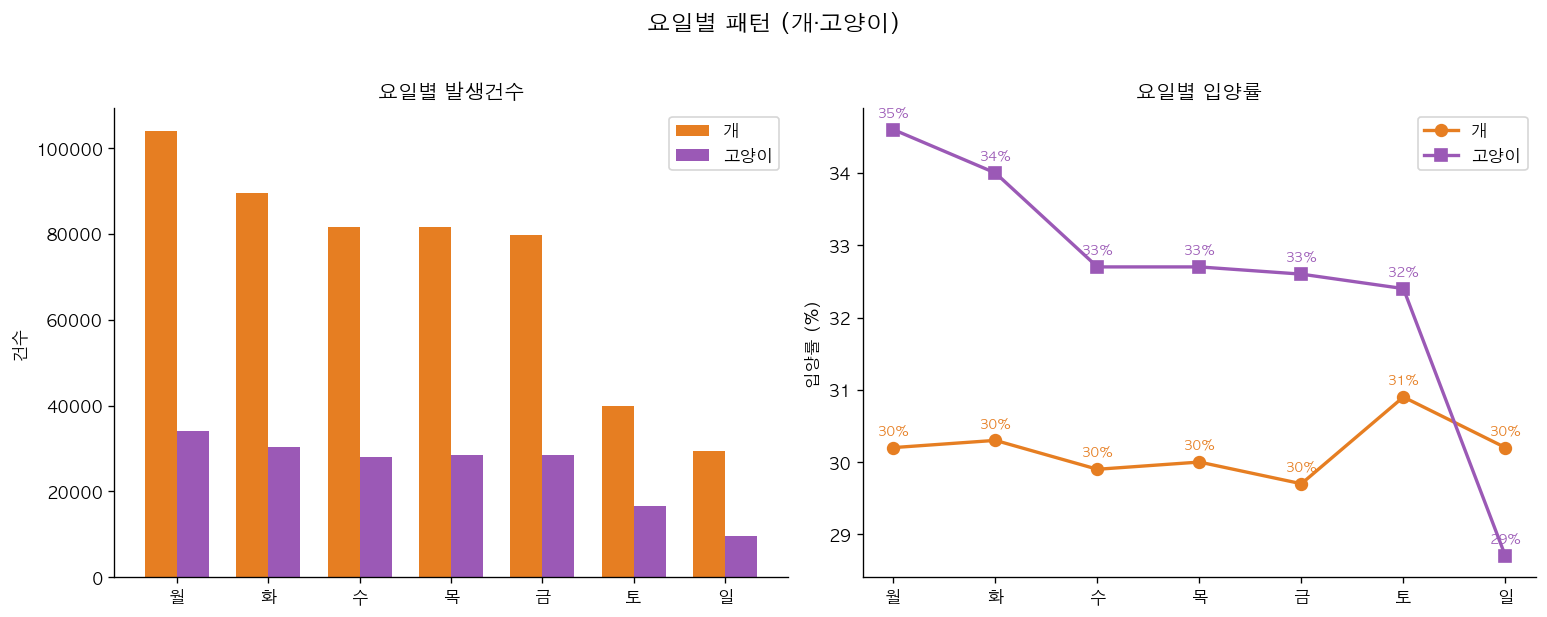

In [14]:
# 4-3. 요일별 발생건수 + 입양률 (개/고양이)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_kr = ['월','화','수','목','금','토','일']

day_agg = T.groupby(['접수요일','동물종류']).agg(총=('총건수','sum'),입양=('입양건수','sum')).reset_index()
day_agg['입양률'] = (day_agg['입양']/day_agg['총']*100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
w = 0.35
for i, (sp, color) in enumerate([('개',PAL['개']),('고양이',PAL['고양이'])]):
    d = day_agg[day_agg['동물종류']==sp].set_index('접수요일').loc[day_order]
    ax.bar([j+i*w for j in range(7)], d['총'], w, color=color, label=sp)
ax.set_xticks([j+w/2 for j in range(7)]); ax.set_xticklabels(day_kr)
ax.set_title('요일별 발생건수', fontweight='bold'); ax.set_ylabel('건수'); ax.legend()
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
for sp, color, mk in [('개',PAL['개'],'o'),('고양이',PAL['고양이'],'s')]:
    d = day_agg[day_agg['동물종류']==sp].set_index('접수요일').loc[day_order]
    ax.plot(day_kr, d['입양률'], f'{mk}-', color=color, lw=2, ms=7, label=sp)
    for j, v in enumerate(d['입양률']):
        ax.annotate(f'{v:.0f}%', (day_kr[j], v), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8, color=color)
ax.set_title('요일별 입양률', fontweight='bold'); ax.set_ylabel('입양률 (%)'); ax.legend()
ax.spines[['top','right']].set_visible(False)

plt.suptitle('요일별 패턴 (개·고양이)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_요일별패턴.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 5. 개 vs 고양이 비교

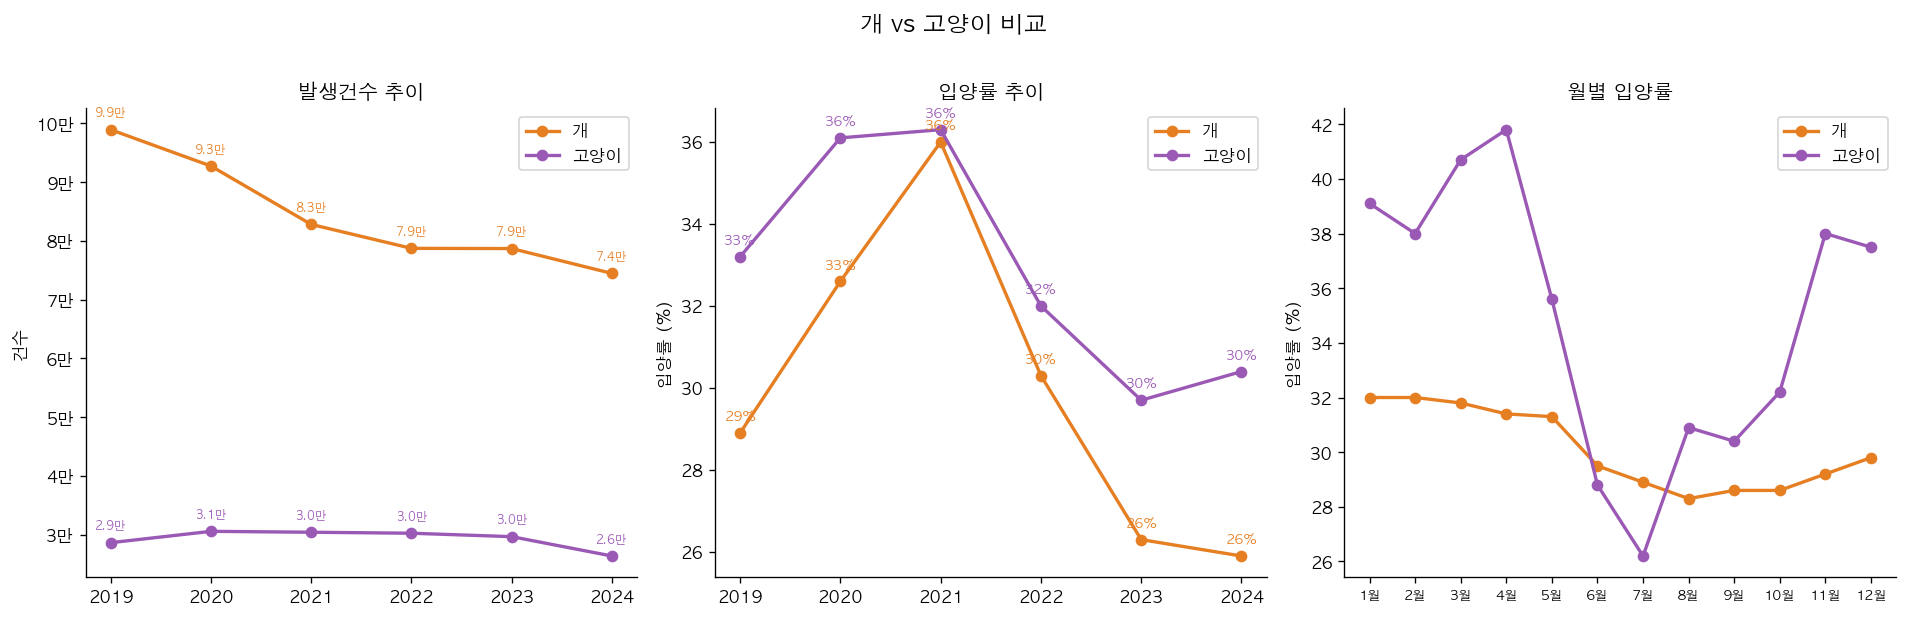

In [15]:
# 연도별 추이
sp_yr = T.groupby(['접수년도','동물종류']).agg(총=('총건수','sum'),입양=('입양건수','sum')).reset_index()
sp_yr['입양률'] = (sp_yr['입양']/sp_yr['총']*100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 발생건수 추이
ax = axes[0]
for sp, color in [('개',PAL['개']),('고양이',PAL['고양이'])]:
    d = sp_yr[sp_yr['동물종류']==sp]
    ax.plot(d['접수년도'], d['총'], 'o-', color=color, lw=2, ms=6, label=sp)
    for _, r in d.iterrows():
        ax.annotate(f'{r["총"]/10000:.1f}만', (r['접수년도'],r['총']), textcoords='offset points', xytext=(0,8), fontsize=7, ha='center', color=color)
ax.set_title('발생건수 추이', fontweight='bold'); ax.set_ylabel('건수')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/10000:.0f}만'))
ax.legend(); ax.spines[['top','right']].set_visible(False)

# 입양률 추이
ax = axes[1]
for sp, color in [('개',PAL['개']),('고양이',PAL['고양이'])]:
    d = sp_yr[sp_yr['동물종류']==sp]
    ax.plot(d['접수년도'], d['입양률'], 'o-', color=color, lw=2, ms=6, label=sp)
    for _, r in d.iterrows():
        ax.annotate(f'{r["입양률"]:.0f}%', (r['접수년도'],r['입양률']), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8, color=color)
ax.set_title('입양률 추이', fontweight='bold'); ax.set_ylabel('입양률 (%)')
ax.legend(); ax.spines[['top','right']].set_visible(False)

# 월별 입양률
ax = axes[2]
sp_m = T.groupby(['접수월','동물종류']).agg(총=('총건수','sum'),입양=('입양건수','sum')).reset_index()
sp_m['입양률'] = (sp_m['입양']/sp_m['총']*100).round(1)
for sp, color in [('개',PAL['개']),('고양이',PAL['고양이'])]:
    d = sp_m[sp_m['동물종류']==sp]
    ax.plot(d['접수월'], d['입양률'], 'o-', color=color, lw=2, ms=6, label=sp)
ax.set_title('월별 입양률', fontweight='bold'); ax.set_ylabel('입양률 (%)')
ax.set_xticks(range(1,13)); ax.set_xticklabels([f'{m}월' for m in range(1,13)], fontsize=8)
ax.legend(); ax.spines[['top','right']].set_visible(False)

plt.suptitle('개 vs 고양이 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_개vs고양이.png', dpi=150, bbox_inches='tight')
plt.show()

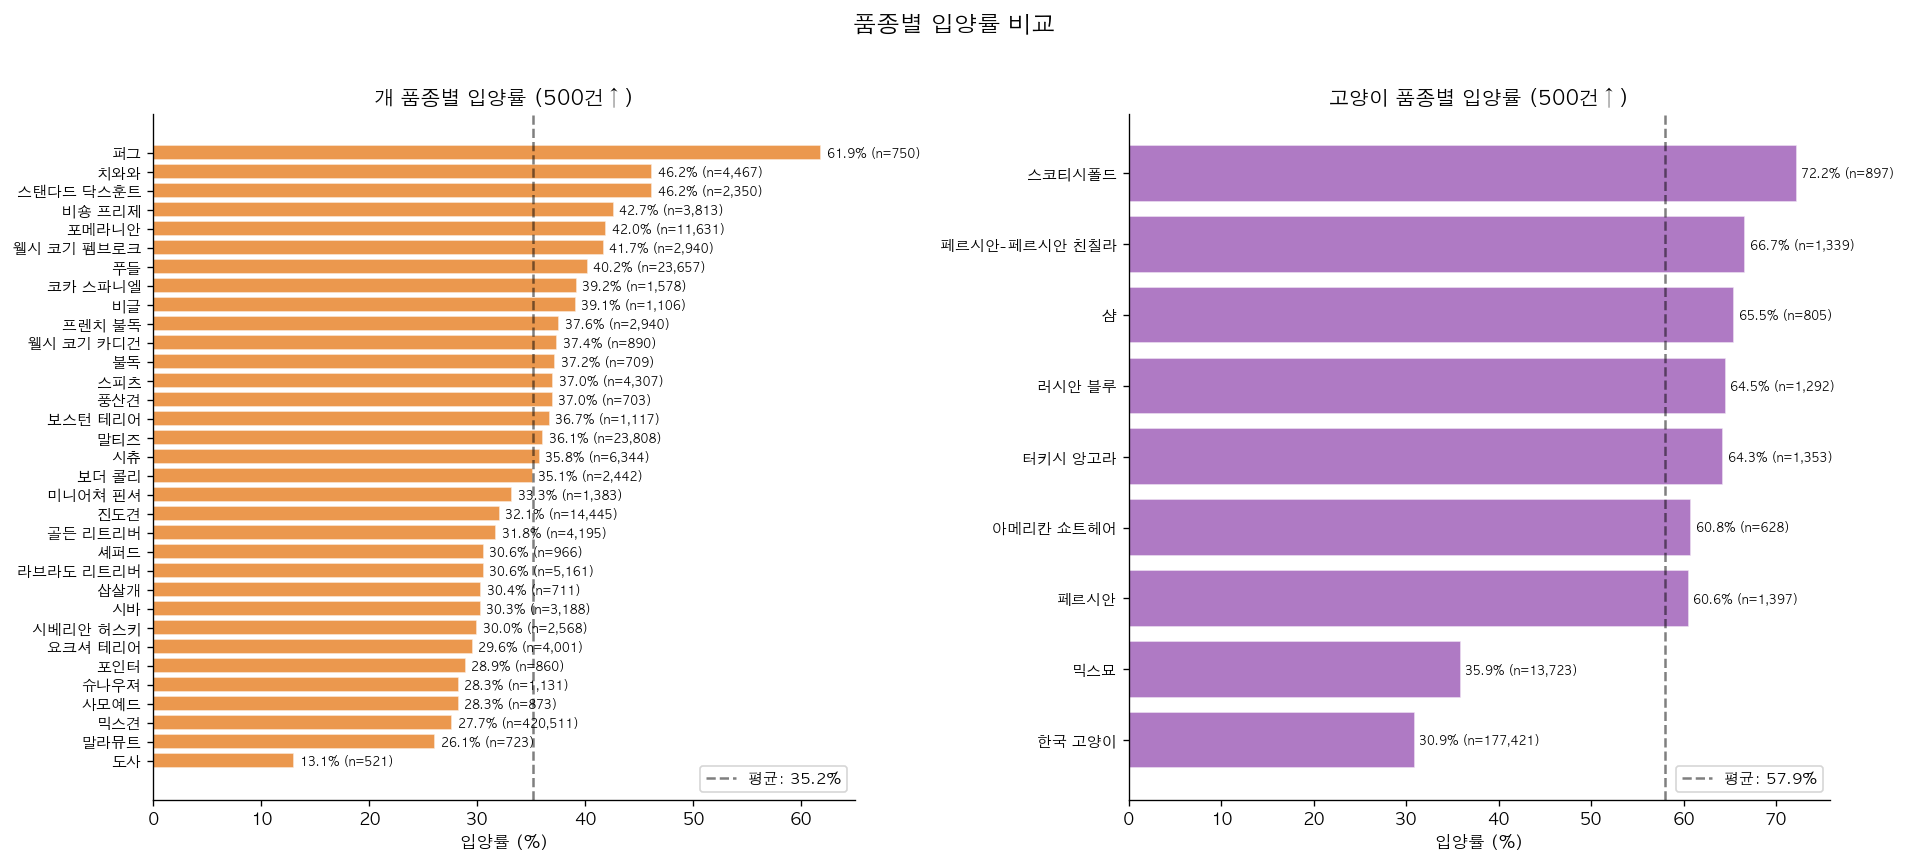

In [16]:
# 5-2. 품종별 입양률 (개/고양이 분리)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, sp, color in zip(axes, ['개','고양이'], [PAL['개'],PAL['고양이']]):
    d = breed[(breed['동물종류']==sp) & (breed['총건수']>=500)].sort_values('입양률', ascending=True)
    bars = ax.barh(range(len(d)), d['입양률'], color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d['품종'], fontsize=9)
    for b, (_, row) in zip(bars, d.iterrows()):
        ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2,
                f'{row["입양률"]:.1f}% (n={row["총건수"]:,.0f})', va='center', fontsize=7)
    avg = d['입양률'].mean()
    ax.axvline(avg, color='black', linestyle='--', alpha=0.5, label=f'평균: {avg:.1f}%')
    ax.set_xlabel('입양률 (%)'); ax.set_title(f'{sp} 품종별 입양률 (500건↑)', fontweight='bold')
    ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

plt.suptitle('품종별 입양률 비교', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_품종별입양률.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 6. 나이·성별·중성화별 입양률

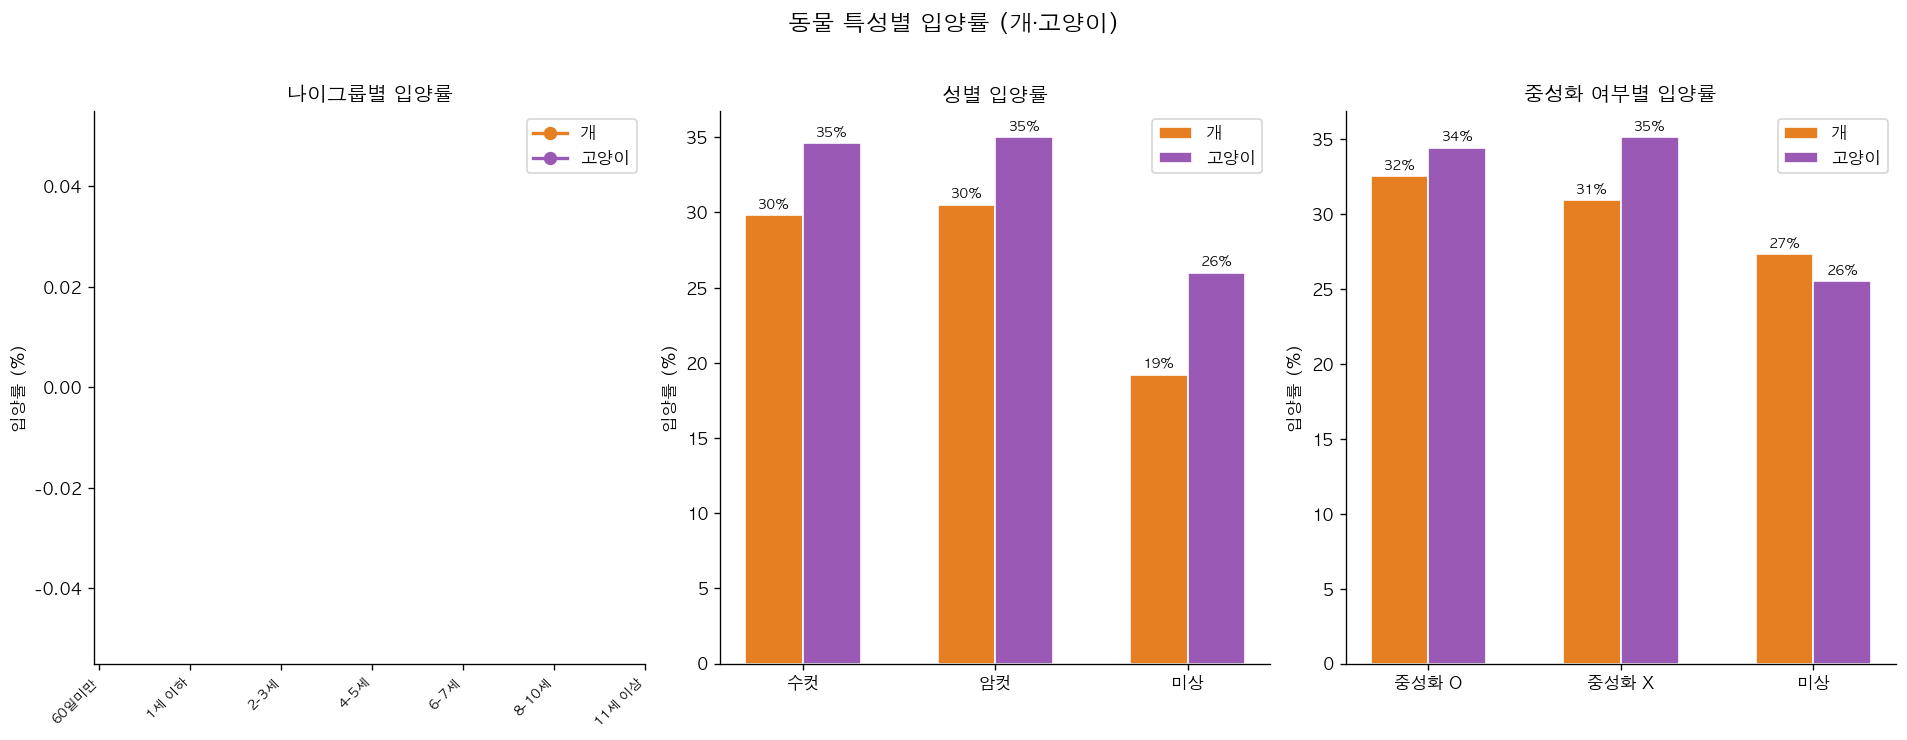

In [17]:
age_order = ['60일미만','1세 이하','2-3세','4-5세','6-7세','8-10세','11세 이상']

def agg_rate(df, group_col):
    return df.groupby([group_col,'동물종류']).agg(총=('총건수','sum'),입양=('입양건수','sum')).reset_index().assign(
        입양률=lambda x: (x['입양']/x['총']*100).round(1))

age_agg  = agg_rate(multidim, '나이그룹')
sex_agg  = agg_rate(multidim, '성별')
neut_agg = agg_rate(multidim, '중성화 여부')

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# 나이그룹별
ax = axes[0]
for sp, color in [('개',PAL['개']),('고양이',PAL['고양이'])]:
    d = age_agg[(age_agg['동물종류']==sp)&(age_agg['나이그룹'].isin(age_order))]
    d = d.set_index('나이그룹').loc[[a for a in age_order if a in d.index]]
    ax.plot(range(len(d)), d['입양률'], 'o-', color=color, lw=2, ms=7, label=sp)
    for j, v in enumerate(d['입양률']):
        ax.annotate(f'{v:.0f}%', (j, v), textcoords='offset points', xytext=(0,8), ha='center', fontsize=7, color=color)
ax.set_xticks(range(len(age_order))); ax.set_xticklabels(age_order, rotation=45, ha='right', fontsize=8)
ax.set_title('나이그룹별 입양률', fontweight='bold'); ax.set_ylabel('입양률 (%)')
ax.legend(); ax.spines[['top','right']].set_visible(False)

# 성별
ax = axes[1]
sex_order = ['수컷','암컷','미상']
x = np.arange(len(sex_order)); w=0.3
for i, (sp, color) in enumerate([('개',PAL['개']),('고양이',PAL['고양이'])]):
    d = sex_agg[(sex_agg['동물종류']==sp)&(sex_agg['성별'].isin(sex_order))].set_index('성별').loc[sex_order]
    bars = ax.bar(x+i*w-w/2, d['입양률'], w, color=color, label=sp, edgecolor='white')
    for b, v in zip(bars, d['입양률']):
        ax.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.0f}%', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(sex_order)
ax.set_title('성별 입양률', fontweight='bold'); ax.set_ylabel('입양률 (%)')
ax.legend(); ax.spines[['top','right']].set_visible(False)

# 중성화
ax = axes[2]
neut_order = ['중성화 O','중성화 X','미상']
for i, (sp, color) in enumerate([('개',PAL['개']),('고양이',PAL['고양이'])]):
    d = neut_agg[(neut_agg['동물종류']==sp)&(neut_agg['중성화 여부'].isin(neut_order))].set_index('중성화 여부').loc[neut_order]
    bars = ax.bar(x+i*w-w/2, d['입양률'], w, color=color, label=sp, edgecolor='white')
    for b, v in zip(bars, d['입양률']):
        ax.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.0f}%', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(neut_order)
ax.set_title('중성화 여부별 입양률', fontweight='bold'); ax.set_ylabel('입양률 (%)')
ax.legend(); ax.spines[['top','right']].set_visible(False)

plt.suptitle('동물 특성별 입양률 (개·고양이)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_특성별입양률.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7. 보호소 성과 분석

In [18]:
sv = shelter[shelter['총보호건수']>=100].copy()

def classify(row):
    if row['입양률']>=50: return 'A. 고입양(50%↑)'
    elif row['안락사율']>=40: return 'D. 고안락사(40%↑)'
    elif row['자연사율']>=40: return 'E. 고자연사(40%↑)'
    elif row['입양률']>=30: return 'B. 중입양(30~50%)'
    else: return 'C. 저입양(30%↓)'

sv['유형'] = sv.apply(classify, axis=1)
sv['규모'] = pd.cut(sv['총보호건수'], bins=[0,500,1000,3000,50000],
                    labels=['소규모(~500)','중규모(500~1k)','대규모(1k~3k)','초대형(3k~)'])

print('=== 보호소 유형별 요약 ===')
ts = sv.groupby('유형').agg(보호소수=('보호소명','count'),
    평균입양률=('입양률','mean'), 평균안락사율=('안락사율','mean'),
    평균자연사율=('자연사율','mean'), 평균보호건수=('총보호건수','mean')).round(1)
print(ts.to_string())
print(f'\n총 {len(sv)}개 보호소')

=== 보호소 유형별 요약 ===
                보호소수  평균입양률  평균안락사율  평균자연사율  평균보호건수
유형                                                 
A. 고입양(50%↑)      69   63.0     5.6    17.4  1177.6
B. 중입양(30~50%)   106   38.6    17.2    22.4  2291.9
C. 저입양(30%↓)      70   24.7    24.3    27.4  2187.4
D. 고안락사(40%↑)     68   18.5    55.1    18.3  2065.9
E. 고자연사(40%↑)     75   22.9    10.2    55.0  2239.7

총 388개 보호소


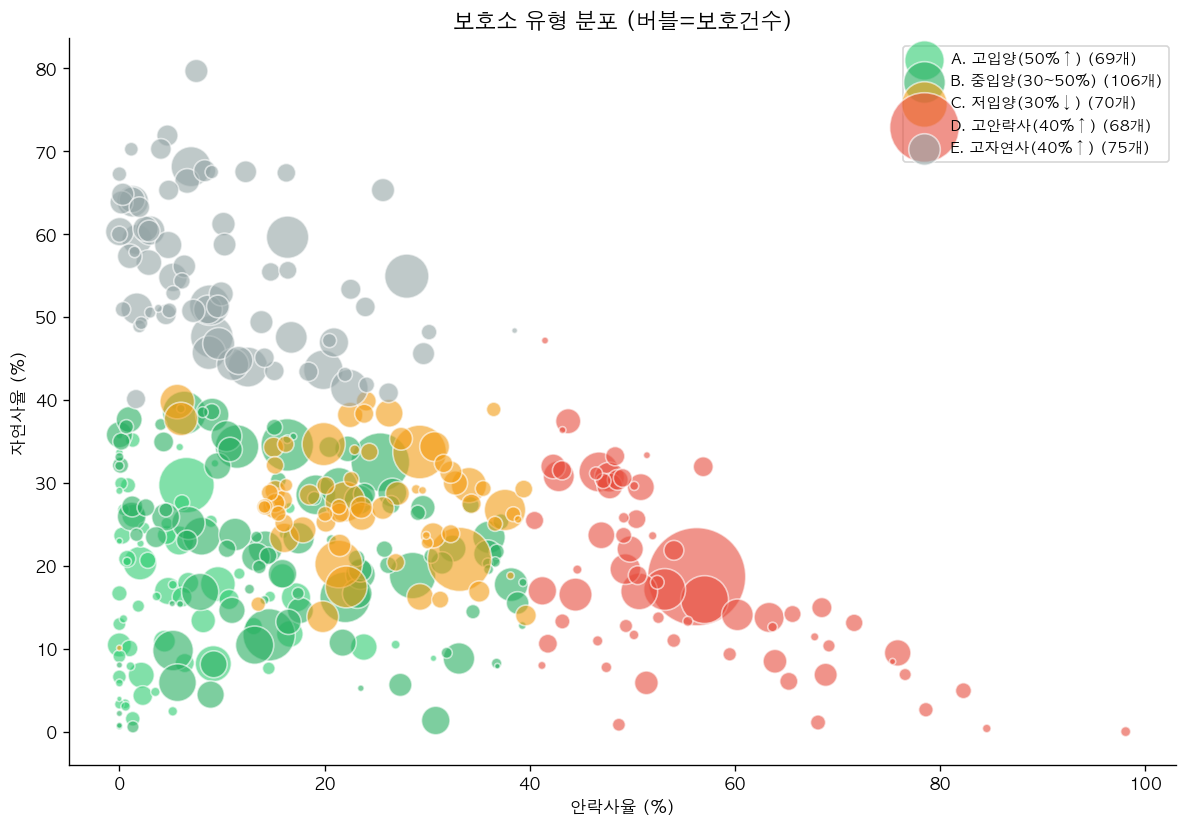

In [19]:
# 7-1. 보호소 유형 산점도
tc = {'A. 고입양(50%↑)':'#2ecc71','B. 중입양(30~50%)':'#27ae60',
      'C. 저입양(30%↓)':'#f39c12','D. 고안락사(40%↑)':'#e74c3c','E. 고자연사(40%↑)':'#95a5a6'}

fig, ax = plt.subplots(figsize=(10, 7))
for t, color in tc.items():
    d = sv[sv['유형']==t]
    if len(d)==0: continue
    ax.scatter(d['안락사율'], d['자연사율'], s=d['총보호건수']/10,
              c=color, alpha=0.6, edgecolors='white', label=f'{t} ({len(d)}개)')
ax.set_xlabel('안락사율 (%)'); ax.set_ylabel('자연사율 (%)')
ax.set_title('보호소 유형 분포 (버블=보호건수)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_보호소유형.png', dpi=150, bbox_inches='tight')
plt.show()

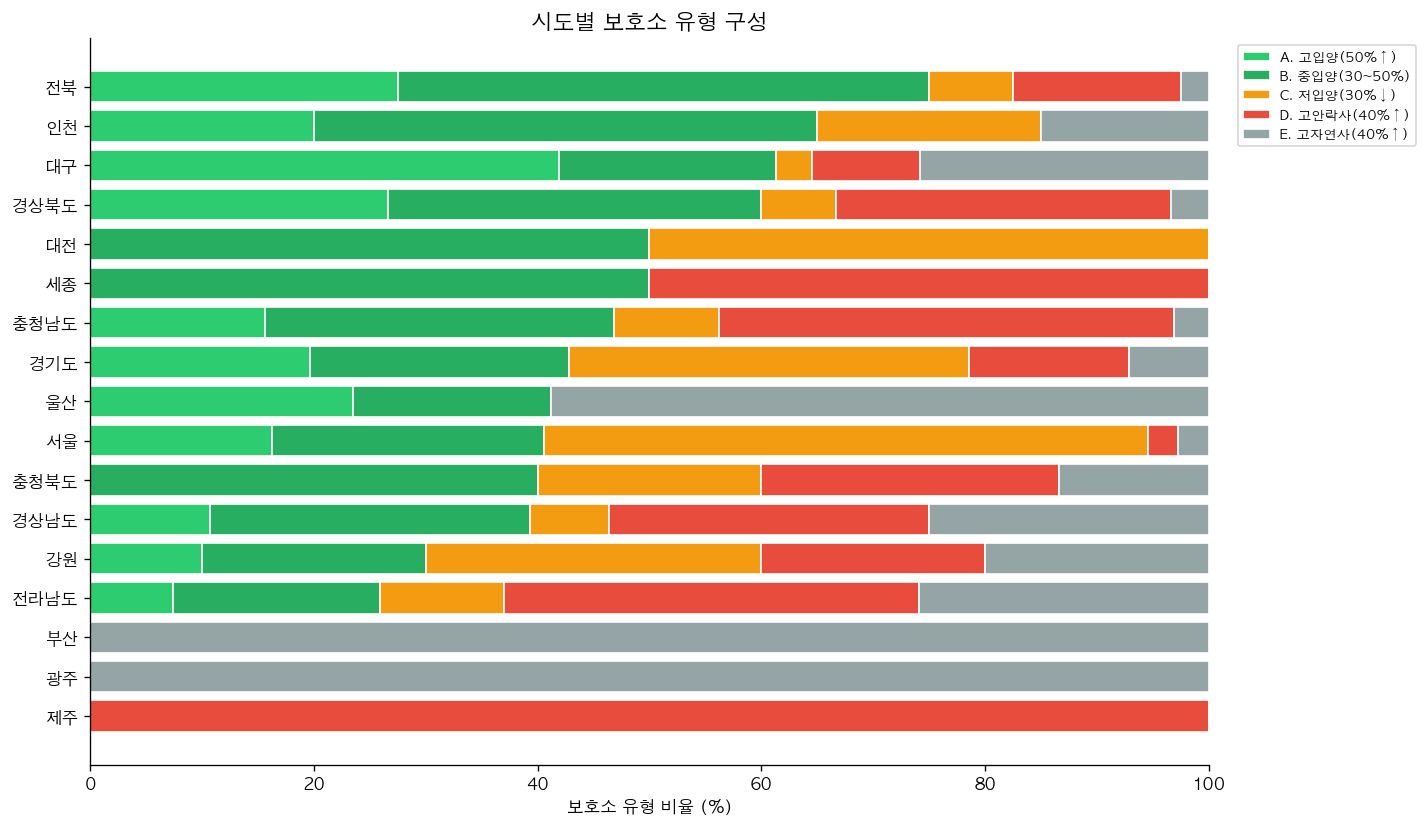

In [20]:
# 7-2. 시도별 보호소 유형 구성
st = sv.groupby(['시도','유형']).size().unstack(fill_value=0)
st_pct = st.div(st.sum(axis=1), axis=0)*100
good = [c for c in ['A. 고입양(50%↑)','B. 중입양(30~50%)'] if c in st_pct.columns]
st_pct['좋은'] = st_pct[good].sum(axis=1) if good else 0
st_pct = st_pct.sort_values('좋은').drop('좋은', axis=1)

fig, ax = plt.subplots(figsize=(12, 7))
bottom = np.zeros(len(st_pct))
for col in st_pct.columns:
    color = tc.get(col, '#333')
    ax.barh(range(len(st_pct)), st_pct[col], left=bottom, color=color, label=col, edgecolor='white')
    bottom += st_pct[col].values
ax.set_yticks(range(len(st_pct)))
ynames = [s.replace('특별자치도','').replace('특별자치시','').replace('광역시','').replace('특별시','') for s in st_pct.index]
ax.set_yticklabels(ynames)
ax.set_xlabel('보호소 유형 비율 (%)'); ax.set_title('시도별 보호소 유형 구성', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_시도별보호소유형.png', dpi=150, bbox_inches='tight')
plt.show()

=== 보호소 규모별 성과 ===
               n   입양률  안락사율  자연사율
규모                                
소규모(~500)     83  41.1  22.3  20.4
중규모(500~1k)   75  35.6  21.9  27.4
대규모(1k~3k)   156  30.4  21.3  31.5
초대형(3k~)      74  31.3  21.6  29.7


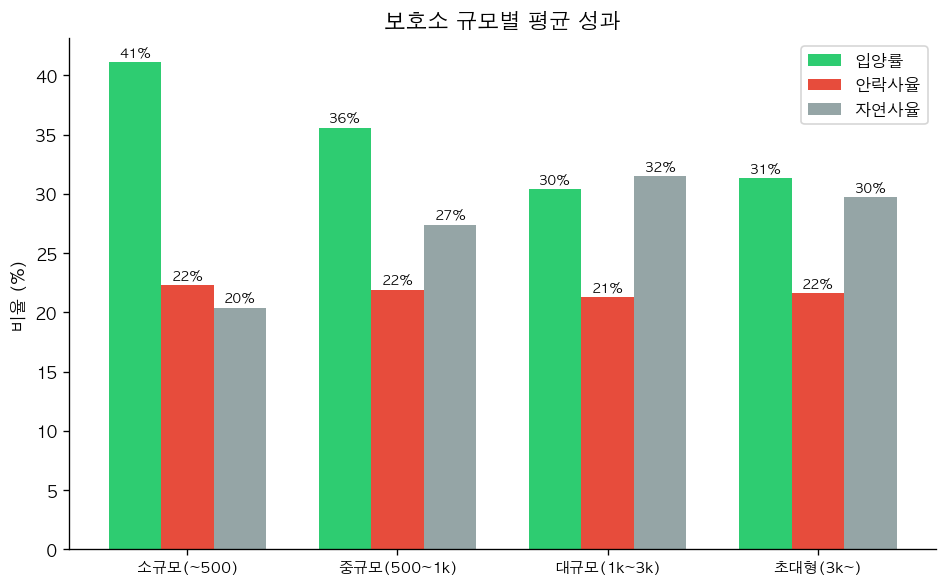

In [21]:
# 7-3. 보호소 규모별 성과
ss = sv.groupby('규모', observed=True).agg(
    n=('보호소명','count'), 입양률=('입양률','mean'),
    안락사율=('안락사율','mean'), 자연사율=('자연사율','mean')).round(1)
print('=== 보호소 규모별 성과 ==='); print(ss.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(ss)); w=0.25
for offset, (col, color) in enumerate([('입양률',PAL['입양']),('안락사율',PAL['안락사']),('자연사율',PAL['자연사'])]):
    bars = ax.bar([i+(offset-1)*w for i in x], ss[col], w, color=color, label=col)
    for b, v in zip(bars, ss[col]):
        ax.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.0f}%', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(ss.index, fontsize=9)
ax.set_ylabel('비율 (%)'); ax.set_title('보호소 규모별 평균 성과', fontsize=13, fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG}EDA_보호소규모별성과.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 종합 요약

In [22]:
print('=' * 70)
print('           Homebound 종합 EDA 핵심 발견 (개·고양이)')
print('=' * 70)

findings = [
    ('전국 추이',
     '발생: 5년 연속 감소 (133k→103k)\n'
     '          입양률 30%→28% 하락, 사망률 55%→54% 고착\n'
     '          사망률이 입양률을 일관되게 20%p 이상 초과'),
    ('시도별 격차',
     '입양률: 제주 15% ~ 경북 39% (24%p 격차)\n'
     '          3개 시도(제주·전남·경기)에서 안락사율 > 입양률\n'
     '          대전·서울: 2019→2024 입양률 상승한 몇 안 되는 지역'),
    ('계절성',
     '발생 피크: 4-6월(번식기), 10월(유기 증가)\n'
     '          입양률 고점: 2-3월 / 저점: 7-8월(휴가철)\n'
     '          주중(월-금) 접수 집중, 주말 발생건수 1/3 수준'),
    ('개 vs 고양이',
     '고양이 비중 증가: 21.5%→25.5% (4%p↑)\n'
     '          고양이 입양률이 개보다 일관되게 높음\n'
     '          개: 믹스견(28%) vs 품종견(36~46%) 격차 심각'),
    ('동물 특성',
     '나이: 어릴수록 입양률 높음 (1세 이하 최고)\n'
     '          중성화 O >> 중성화 X (현저한 차이)\n'
     '          성별: 암컷이 수컷보다 입양률 약간 높음'),
    ('보호소 구조',
     '규모↑ → 입양률↓, 안락사율↑ (구조적 문제)\n'
     '          고안락사형(40%↑) 보호소가 상당수 존재\n'
     '          제주·경기: 저입양+고안락사 보호소 집중'),
]

for title, desc in findings:
    print(f'\n[{title}]\n  {desc}')

print('\n' + '=' * 70)

           Homebound 종합 EDA 핵심 발견 (개·고양이)

[전국 추이]
  발생: 5년 연속 감소 (133k→103k)
          입양률 30%→28% 하락, 사망률 55%→54% 고착
          사망률이 입양률을 일관되게 20%p 이상 초과

[시도별 격차]
  입양률: 제주 15% ~ 경북 39% (24%p 격차)
          3개 시도(제주·전남·경기)에서 안락사율 > 입양률
          대전·서울: 2019→2024 입양률 상승한 몇 안 되는 지역

[계절성]
  발생 피크: 4-6월(번식기), 10월(유기 증가)
          입양률 고점: 2-3월 / 저점: 7-8월(휴가철)
          주중(월-금) 접수 집중, 주말 발생건수 1/3 수준

[개 vs 고양이]
  고양이 비중 증가: 21.5%→25.5% (4%p↑)
          고양이 입양률이 개보다 일관되게 높음
          개: 믹스견(28%) vs 품종견(36~46%) 격차 심각

[동물 특성]
  나이: 어릴수록 입양률 높음 (1세 이하 최고)
          중성화 O >> 중성화 X (현저한 차이)
          성별: 암컷이 수컷보다 입양률 약간 높음

[보호소 구조]
  규모↑ → 입양률↓, 안락사율↑ (구조적 문제)
          고안락사형(40%↑) 보호소가 상당수 존재
          제주·경기: 저입양+고안락사 보호소 집중

